Dataset Shape: (30000, 24)
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0    20000.0    2          2         1   24      2      2     -1     -1   
1   120000.0    2          2         2   26     -1      2      0      0   
2    90000.0    2          2         2   34      0      0      0      0   
3    50000.0    2          2         1   37      0      0      0      0   
4    50000.0    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1      0  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2      0  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3      0  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4      0  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.

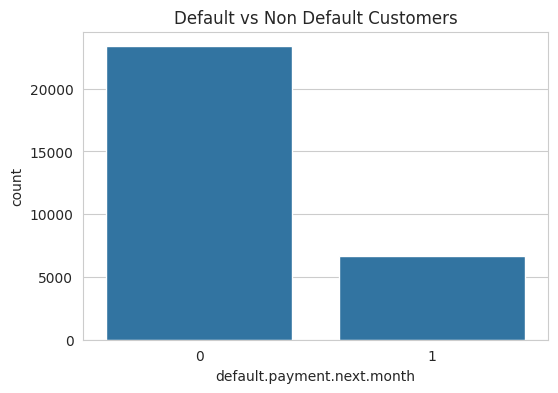

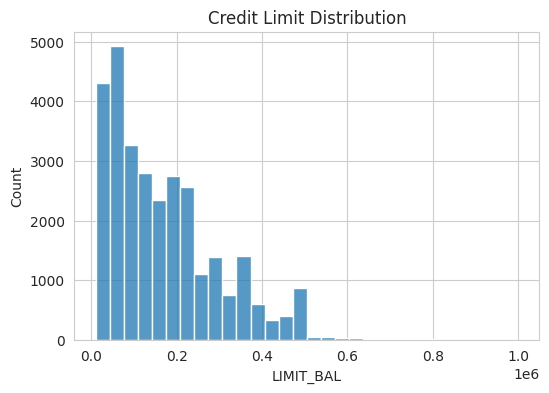

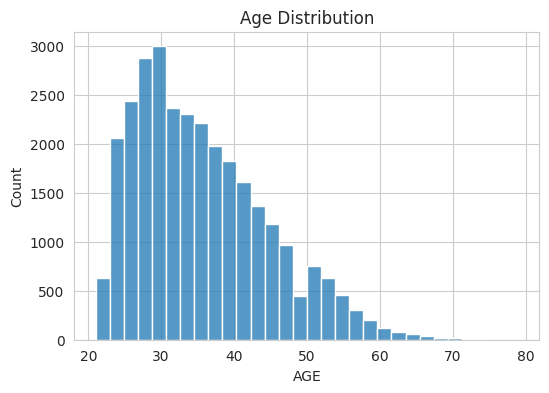

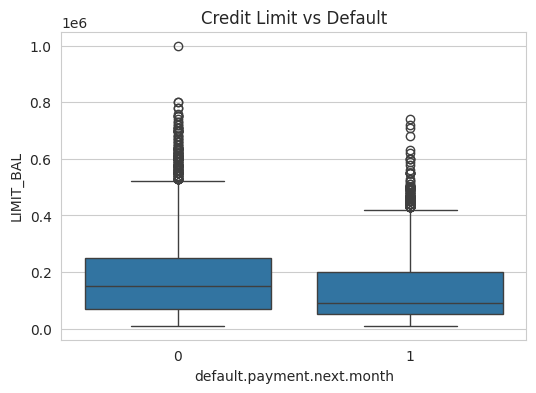

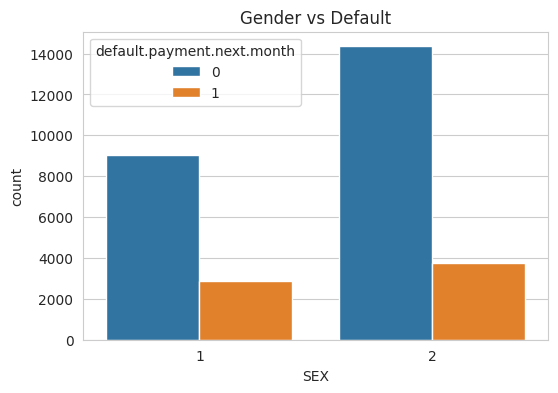

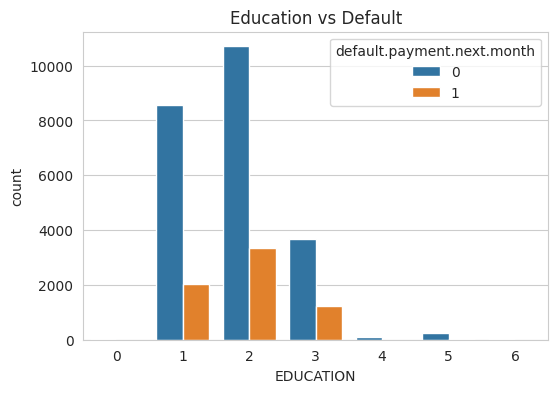

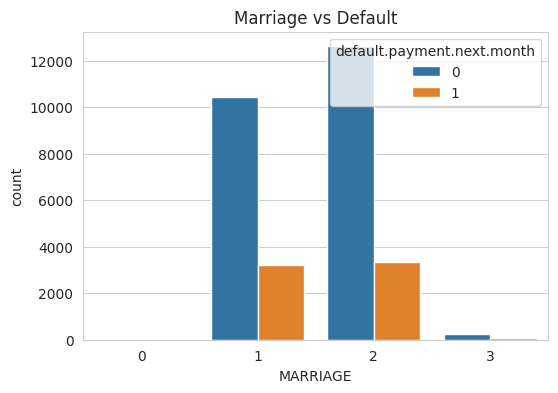

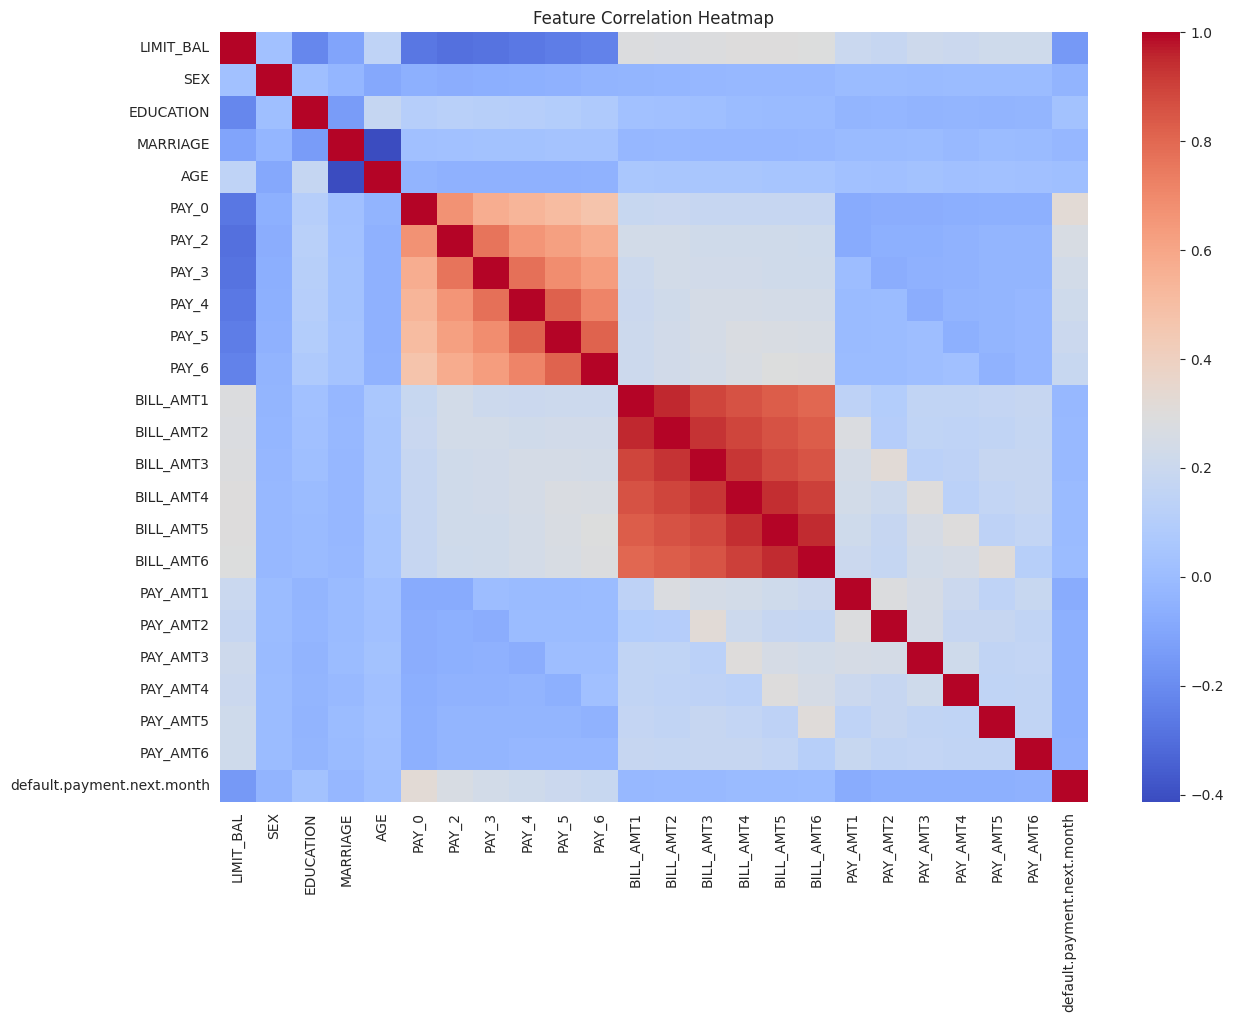

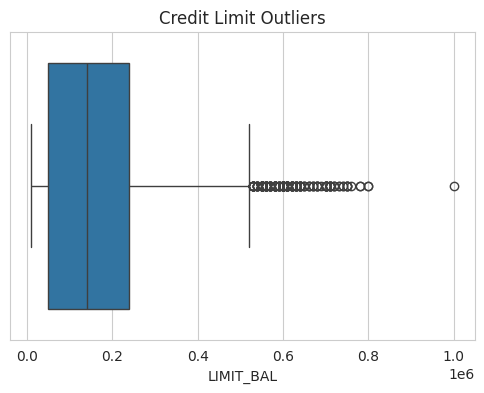


Before SMOTE
default.payment.next.month
0    18024
1     5233
Name: count, dtype: int64

After SMOTE
default.payment.next.month
0    18024
1    18024
Name: count, dtype: int64

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      4516
           1       0.38      0.63      0.48      1299

    accuracy                           0.69      5815
   macro avg       0.63      0.67      0.63      5815
weighted avg       0.76      0.69      0.71      5815

ROC AUC: 0.6693696554752548


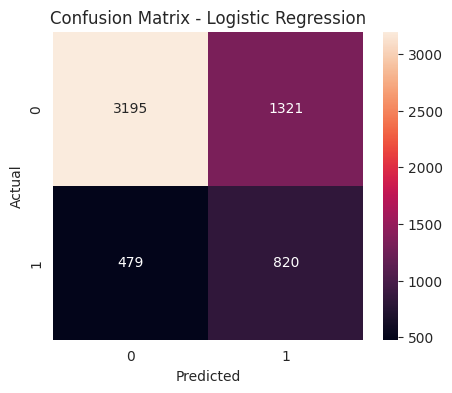


RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4516
           1       0.56      0.47      0.51      1299

    accuracy                           0.80      5815
   macro avg       0.71      0.68      0.69      5815
weighted avg       0.79      0.80      0.79      5815

ROC AUC: 0.6833019846976381


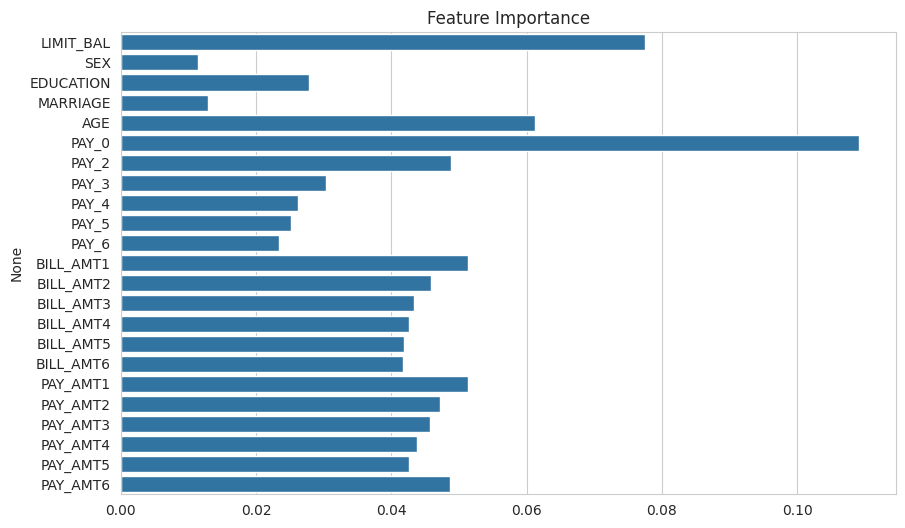


XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      4516
           1       0.58      0.42      0.48      1299

    accuracy                           0.80      5815
   macro avg       0.71      0.66      0.68      5815
weighted avg       0.79      0.80      0.79      5815

ROC AUC: 0.6648938237562313


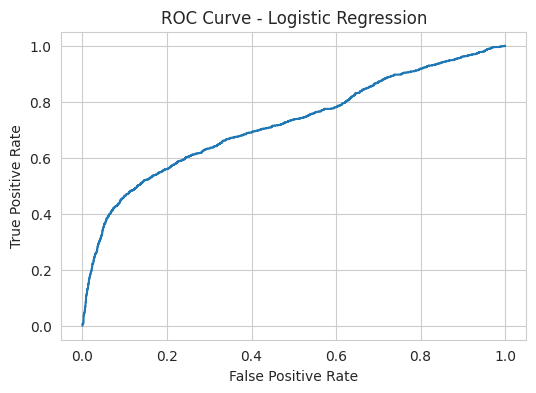

In [7]:
# =====================================================
# CREDIT CARD DEFAULT PREDICTION PROJECT
# =====================================================

# -------------------------------
# 1. Import Libraries
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


# -------------------------------
# 2. Load Dataset
# -------------------------------

df = pd.read_csv("UCI_Credit_Card.csv")

# Remove ID column
df.drop("ID", axis=1, inplace=True)

print("Dataset Shape:", df.shape)
print(df.head())


# -------------------------------
# 3. Check Missing Values
# -------------------------------

print("\nMissing Values")
print(df.isnull().sum())


# -------------------------------
# 4. Exploratory Data Analysis (Graphs)
# -------------------------------

# Default Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='default.payment.next.month', data=df)
plt.title("Default vs Non Default Customers")
plt.show()


# Credit Limit Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['LIMIT_BAL'], bins=30)
plt.title("Credit Limit Distribution")
plt.show()


# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['AGE'], bins=30)
plt.title("Age Distribution")
plt.show()


# Credit Limit vs Default

plt.figure(figsize=(6,4))
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df)
plt.title("Credit Limit vs Default")
plt.show()


# Gender vs Default

plt.figure(figsize=(6,4))
sns.countplot(x='SEX', hue='default.payment.next.month', data=df)
plt.title("Gender vs Default")
plt.show()


# Education vs Default

plt.figure(figsize=(6,4))
sns.countplot(x='EDUCATION', hue='default.payment.next.month', data=df)
plt.title("Education vs Default")
plt.show()


# Marriage vs Default

plt.figure(figsize=(6,4))
sns.countplot(x='MARRIAGE', hue='default.payment.next.month', data=df)
plt.title("Marriage vs Default")
plt.show()


# Correlation Heatmap

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


# -------------------------------
# 5. Outlier Handling
# -------------------------------

plt.figure(figsize=(6,4))
sns.boxplot(x=df['LIMIT_BAL'])
plt.title("Credit Limit Outliers")
plt.show()

# Remove extreme outliers

df = df[df['LIMIT_BAL'] < df['LIMIT_BAL'].quantile(0.99)]


# -------------------------------
# 6. Features and Target
# -------------------------------

X = df.drop("default.payment.next.month", axis=1)
y = df["default.payment.next.month"]


# -------------------------------
# 7. Train Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# -------------------------------
# 8. Feature Scaling
# -------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -------------------------------
# 9. Handle Class Imbalance (SMOTE)
# -------------------------------

print("\nBefore SMOTE")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())


# =====================================================
# 10. LOGISTIC REGRESSION
# =====================================================

lr = LogisticRegression()

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

print("\nLOGISTIC REGRESSION RESULTS")

print(classification_report(y_test, y_pred_lr))

print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))


# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# =====================================================
# 11. RANDOM FOREST
# =====================================================

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("\nRANDOM FOREST RESULTS")

print(classification_report(y_test, y_pred_rf))

print("ROC AUC:", roc_auc_score(y_test, y_pred_rf))


# Feature Importance Graph

importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=features)
plt.title("Feature Importance")
plt.show()


# =====================================================
# 12. XGBOOST
# =====================================================

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBOOST RESULTS")

print(classification_report(y_test, y_pred_xgb))

print("ROC AUC:", roc_auc_score(y_test, y_pred_xgb))


# =====================================================
# 13. ROC Curve
# =====================================================

lr_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, lr_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()